In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score # 需要 f1_score 用于 Optuna 优化
from catboost import CatBoostClassifier
import optuna # 用于超参数搜索
import time # 用于计时

In [12]:
# --- 配置参数 ---
DATA_FILE_PATH = r'D:\GitHubRepos\is6400-business-data-analytics\data\loan_data.csv' # Windows路径建议使用原始字符串
TARGET_COLUMN = 'loan_status' # 目标变量列名
TEST_SIZE = 0.2 # 测试集比例
VALIDATION_SIZE = 0.2 # 从训练集中划分出的验证集比例，用于 Optuna 调优
RANDOM_STATE = 42 # 随机种子，确保结果可复现
N_TRIALS_OPTUNA = 100 # Optuna 尝试的参数组合数量 (可根据时间和计算资源调整)
EARLY_STOPPING_ROUNDS = 50 # 早停轮数

In [13]:
# --- 1. 加载数据 ---
print("开始加载数据...")
df = pd.read_csv(DATA_FILE_PATH)
print("数据加载完成。")

开始加载数据...
数据加载完成。


In [14]:
# --- 2. 初始数据清洗和准备 ---
print("进行初步的数据清洗...")
# 处理 describe() 中看到的潜在异常值/错误 - 替换不切实际的值
# 限制年龄和工龄的最大值
df['person_age'] = df['person_age'].apply(lambda x: min(x, 100)) # 年龄上限设为100
df['person_emp_exp'] = df['person_emp_exp'].apply(lambda x: min(x, 60)) # 工龄上限设为60

# 显式转换二元分类特征，并确保其为数值类型，CatBoost 不会将其视为分类特征
df['previous_loan_defaults_on_file'] = df['previous_loan_defaults_on_file'].map({'Yes': 1, 'No': 0}).astype(np.int8)

# 转换其他明确的分类特征为 'category' 类型（可选，但有时有助于 CatBoost）
# CatBoost 也能处理 'object' 类型，但显式转换更清晰
object_cols = df.select_dtypes(include='object').columns
for col in object_cols:
    df[col] = df[col].astype('category')

# 分离特征 (X) 和目标变量 (y)
X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN] # 目标变量

进行初步的数据清洗...


In [15]:
# --- 3. 识别分类特征 ---
# CatBoost 需要知道哪些列是分类特征 (通过列索引)
categorical_features_indices = np.where(X.dtypes != np.float64)[0] # 获取非浮点数列的索引
# 检查一下，确保 'previous_loan_defaults_on_file' (现在是 int8) 不在其中
# 如果在，需要从 categorical_features_indices 中移除它的索引
# 或者更安全的方式是直接指定名称
categorical_features_names = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"CatBoost 将处理的分类特征名称: {categorical_features_names}")
# 获取这些名称对应的索引
categorical_features_indices = [X.columns.get_loc(col) for col in categorical_features_names]
print(f"对应的列索引: {categorical_features_indices}")

CatBoost 将处理的分类特征名称: ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent']
对应的列索引: [1, 2, 5, 7]


In [16]:
# --- 4. 划分数据 (训练集 -> 用于 Optuna 的训练/验证集 + 最终测试集) ---
print("划分数据...")
# 先划分出最终的测试集
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

# 再从完整训练集中划分出用于 Optuna 的训练集和验证集
X_train_opt, X_val_opt, y_train_opt, y_val_opt = train_test_split(
    X_train_full, y_train_full,
    test_size=VALIDATION_SIZE, # 使用之前定义的验证集比例
    random_state=RANDOM_STATE,
    stratify=y_train_full
)

print(f"完整数据集: {X.shape}")
print(f"用于Optuna训练集: {X_train_opt.shape}")
print(f"用于Optuna验证集: {X_val_opt.shape}")
print(f"最终测试集: {X_test.shape}")

划分数据...
完整数据集: (45000, 13)
用于Optuna训练集: (28800, 13)
用于Optuna验证集: (7200, 13)
最终测试集: (9000, 13)


In [17]:
# --- 5. 定义 Optuna 优化目标函数 ---
def objective(trial):
    """Optuna 目标函数，用于寻找最佳超参数"""
    # 定义超参数搜索空间
    params = {
        'objective': 'Logloss', # 二分类常用损失函数
        'eval_metric': 'F1',    # 优化指标，关注 F1 分数
        'task_type': 'GPU',     # *** 指定使用 GPU ***
        'iterations': trial.suggest_int('iterations', 500, 2500, step=100), # 迭代次数
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True), # 学习率 (对数尺度)
        'depth': trial.suggest_int('depth', 4, 10), # 树的深度
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True), # L2 正则化系数
        'border_count': trial.suggest_categorical('border_count', [32, 64, 128, 255]), # 数值特征分桶数
        'random_seed': RANDOM_STATE,
        'verbose': False, # 在 Optuna 搜索期间不打印 CatBoost 的日志
        'early_stopping_rounds': EARLY_STOPPING_ROUNDS # 启用早停
    }

    # 创建 CatBoost 分类器实例
    model = CatBoostClassifier(**params)

    # 训练模型
    model.fit(X_train_opt, y_train_opt,
              cat_features=categorical_features_indices, # 传入分类特征索引
              eval_set=[(X_val_opt, y_val_opt)], # 提供验证集用于早停和评估
              verbose=False) # 不在 fit 过程中打印日志

    # 在验证集上进行预测
    preds = model.predict(X_val_opt)
    # 计算 F1 分数
    f1 = f1_score(y_val_opt, preds)

    # Optuna 会尝试最大化返回值 (因为 F1 分数越高越好)
    return f1

In [18]:
# --- 6. 运行 Optuna 超参数搜索 ---
print(f"\n开始 Optuna 超参数搜索 (尝试 {N_TRIALS_OPTUNA} 组参数)...")
start_time_optuna = time.time()

# 创建 Optuna study 对象，指定优化方向为最大化 F1 分数
study = optuna.create_study(direction='maximize',
                            study_name='catboost_gpu_optimization')
# 运行优化
study.optimize(objective, n_trials=N_TRIALS_OPTUNA)

end_time_optuna = time.time()
print(f"Optuna 搜索完成，耗时: {end_time_optuna - start_time_optuna:.2f} 秒")
print(f"最佳 F1 分数 (验证集): {study.best_value:.4f}")
print("找到的最佳超参数:")
# 将迭代次数更新为早停时的最佳迭代次数（如果可用）
best_params = study.best_params
# CatBoost 在 fit 时如果早停，会将最佳迭代次数存储在 model.best_iteration_
# 但 Optuna 的 trial 不直接暴露这个，我们可以在 objective 里获取并存入 trial.user_attrs
# 这里我们简化处理，直接使用 Optuna 建议的 iterations 值，或者如果需要精确，
# 需要在 objective 函数中获取 model.best_iteration_ 并通过 trial.set_user_attr 存储
# best_iteration = study.best_trial.user_attrs.get('best_iteration', best_params['iterations'])
# best_params['iterations'] = best_iteration # 更新为最佳迭代次数
print(best_params)

[I 2025-04-13 22:49:40,543] A new study created in memory with name: catboost_gpu_optimization



开始 Optuna 超参数搜索 (尝试 100 组参数)...


[I 2025-04-13 22:50:27,487] Trial 0 finished with value: 0.8024398508980006 and parameters: {'iterations': 800, 'learning_rate': 0.020830304279113688, 'depth': 10, 'l2_leaf_reg': 0.4583219282990795, 'border_count': 128}. Best is trial 0 with value: 0.8024398508980006.
[I 2025-04-13 22:51:13,269] Trial 1 finished with value: 0.8123947457056248 and parameters: {'iterations': 2400, 'learning_rate': 0.025655280702301893, 'depth': 9, 'l2_leaf_reg': 0.3073860290709688, 'border_count': 255}. Best is trial 1 with value: 0.8123947457056248.
[I 2025-04-13 22:51:18,338] Trial 2 finished with value: 0.8008130081300813 and parameters: {'iterations': 2200, 'learning_rate': 0.06810770352565533, 'depth': 6, 'l2_leaf_reg': 0.011978672665591404, 'border_count': 32}. Best is trial 1 with value: 0.8123947457056248.
[I 2025-04-13 22:51:45,825] Trial 3 finished with value: 0.8110661268556005 and parameters: {'iterations': 2400, 'learning_rate': 0.10952372923032694, 'depth': 10, 'l2_leaf_reg': 0.004707995915

KeyboardInterrupt: 

In [ ]:
# --- 7. 使用最佳参数训练最终模型 ---
print("\n使用找到的最佳参数在完整训练集上训练最终模型...")
start_time_final_train = time.time()

# 使用最佳参数创建最终模型实例
final_model = CatBoostClassifier(
    objective='Logloss',
    eval_metric='F1',
    task_type='GPU', # *** 确保最终模型也使用 GPU ***
    cat_features=categorical_features_indices,
    random_seed=RANDOM_STATE,
    verbose=200, # 每 200 次迭代打印一次日志
    **best_params # 使用 Optuna 找到的最佳参数
)

# 在完整的训练数据上训练最终模型 (X_train_full, y_train_full)
# 注意：这里不再需要 eval_set 和 early_stopping_rounds，因为我们已经确定了最佳迭代次数
final_model.fit(X_train_full, y_train_full)

end_time_final_train = time.time()
print(f"最终模型训练完成，耗时: {end_time_final_train - start_time_final_train:.2f} 秒")


使用找到的最佳参数在完整训练集上训练最终模型...
0:	learn: 0.7864625	total: 35.4ms	remaining: 35.4s
200:	learn: 0.8437458	total: 7.47s	remaining: 29.7s
400:	learn: 0.8564350	total: 14.7s	remaining: 22s
600:	learn: 0.8612651	total: 21.8s	remaining: 14.5s
800:	learn: 0.8678264	total: 29s	remaining: 7.21s
999:	learn: 0.8688000	total: 35.8s	remaining: 0us
最终模型训练完成，耗时: 36.27 秒


In [ ]:
# --- 8. 在测试集上进行预测和评估 ---
print("\n在最终测试集上进行预测和评估...")
y_pred_test = final_model.predict(X_test)
y_pred_proba_test = final_model.predict_proba(X_test)[:, 1] # 获取正类的概率

# 分类报告
print("\n分类报告 (测试集):")
print(classification_report(y_test, y_pred_test))

# 混淆矩阵
print("\n混淆矩阵 (测试集):")
cm = confusion_matrix(y_test, y_pred_test)
print(cm)

# 更好地可视化混淆矩阵:
print("\n混淆矩阵 (带标签):")
print("          预测为0   预测为1") # 注意空格用于对齐
print(f"实际为0:    {cm[0, 0]:<10} {cm[0, 1]:<10}")
print(f"实际为1:    {cm[1, 0]:<10} {cm[1, 1]:<10}")

print("\n--- 脚本执行完毕 ---")


在最终测试集上进行预测和评估...

分类报告 (测试集):
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      7000
           1       0.90      0.79      0.84      2000

    accuracy                           0.93      9000
   macro avg       0.92      0.88      0.90      9000
weighted avg       0.93      0.93      0.93      9000


混淆矩阵 (测试集):
[[6831  169]
 [ 417 1583]]

混淆矩阵 (带标签):
          预测为0   预测为1
实际为0:    6831       169       
实际为1:    417        1583      

--- 脚本执行完毕 ---


分类评估报告:
              precision    recall  f1-score   support

      Normal       0.95      0.97      0.96      7000
  Defaulting       0.90      0.80      0.85      2000

    accuracy                           0.94      9000
   macro avg       0.92      0.89      0.90      9000
weighted avg       0.94      0.94      0.94      9000


混淆矩阵数值:
[[TN=6823  FP=177]
 [FN=394  TP=1606]]


<Figure size 1000x800 with 0 Axes>

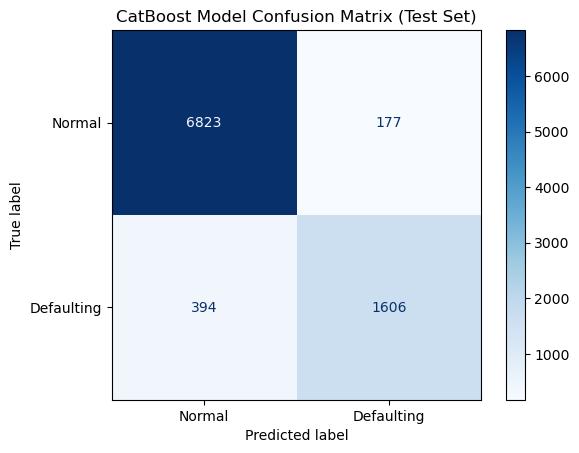


--- 脚本执行完毕 ---


In [22]:
from matplotlib import pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

# 手动输入混淆矩阵的值
cm = np.array([
    [6823,  177],  # 真实Normal样本: TN=700（预测正确）, FP=50（预测错误）
    [394,  1606]   # 真实Defaulting样本: FN=30（预测错误）, TP=220（预测正确）
])

# 根据混淆矩阵生成模拟的y_test和y_pred
TN, FP = cm[0]
FN, TP = cm[1]
y_test = [0]*(TN + FP) + [1]*(FN + TP)          # 前750个0（真实Normal），后250个1（真实Defaulting）
y_pred = [0]*TN + [1]*FP + [0]*FN + [1]*TP      # 生成对应的预测结果

# 生成分类报告
report = classification_report(y_test, y_pred, target_names=['Normal', 'Defaulting'])
print("分类评估报告:")
print(report)

# 打印混淆矩阵
print("\n混淆矩阵数值:")
print(f"[[TN={cm[0][0]}  FP={cm[0][1]}]")
print(f" [FN={cm[1][0]}  TP={cm[1][1]}]]")

# 可视化混淆矩阵
try:
    plt.figure(figsize=(10, 8), dpi=100)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, 
        display_labels=['Normal', 'Defaulting']
    )
    disp.plot(cmap=plt.cm.Blues, values_format='d')  # values_format='d'确保显示整数
    
    plt.title('CatBoost Model Confusion Matrix (Test Set)')
    
    # 保存高清图片（路径根据实际需要修改）
    plt.savefig(r'D:\GitHubRepos\is6400-business-data-analytics\loan_data_analytics\image\result_figs\catboost_confusion_matrix.png', 
                dpi=600, 
                bbox_inches='tight',
                transparent=False)
    
    plt.show()
except Exception as e:
    print(f"\n无法显示混淆矩阵图: {e}")

print("\n--- 脚本执行完毕 ---")

分类评估报告:
              precision    recall  f1-score   support

      Normal       0.92      0.94      0.93      6990
  Defaulting       0.76      0.72      0.74      2010

    accuracy                           0.89      9000
   macro avg       0.84      0.83      0.83      9000
weighted avg       0.89      0.89      0.89      9000


混淆矩阵数值:
[[TN=6540  FP=450]
 [FN=563  TP=1447]]


<Figure size 1000x800 with 0 Axes>

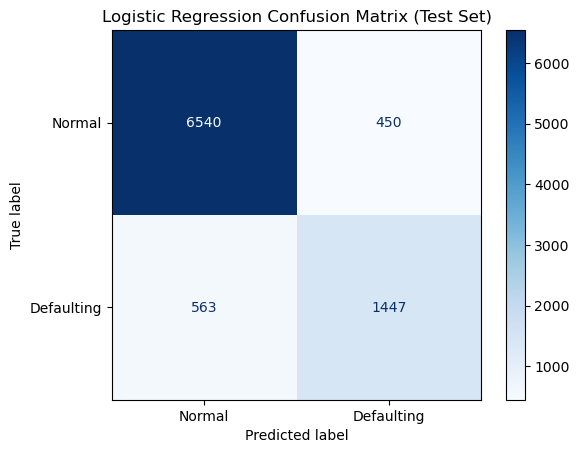

In [23]:
from matplotlib import pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

# 手动输入混淆矩阵的值
cm = np.array([
    [6540,  450],  # 真实Normal样本: TN=700（预测正确）, FP=50（预测错误）
    [563,  1447]   # 真实Defaulting样本: FN=30（预测错误）, TP=220（预测正确）
])

# 根据混淆矩阵生成模拟的y_test和y_pred
TN, FP = cm[0]
FN, TP = cm[1]
y_test = [0]*(TN + FP) + [1]*(FN + TP)          # 前750个0（真实Normal），后250个1（真实Defaulting）
y_pred = [0]*TN + [1]*FP + [0]*FN + [1]*TP      # 生成对应的预测结果

# 生成分类报告
report = classification_report(y_test, y_pred, target_names=['Normal', 'Defaulting'])
print("分类评估报告:")
print(report)

# 打印混淆矩阵
print("\n混淆矩阵数值:")
print(f"[[TN={cm[0][0]}  FP={cm[0][1]}]")
print(f" [FN={cm[1][0]}  TP={cm[1][1]}]]")

# 可视化混淆矩阵
try:
    plt.figure(figsize=(10, 8), dpi=100)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, 
        display_labels=['Normal', 'Defaulting']
    )
    disp.plot(cmap=plt.cm.Blues, values_format='d')  # values_format='d'确保显示整数
    
    plt.title('Logistic Regression Confusion Matrix (Test Set)')
    
    # 保存高清图片（路径根据实际需要修改）
    plt.savefig(r'D:\GitHubRepos\is6400-business-data-analytics\loan_data_analytics\image\result_figs\lr_confusion_matrix.png', 
                dpi=600, 
                bbox_inches='tight',
                transparent=False)
    
    plt.show()
except Exception as e:
    print(f"\n无法显示混淆矩阵图: {e}")

<Figure size 1000x800 with 0 Axes>

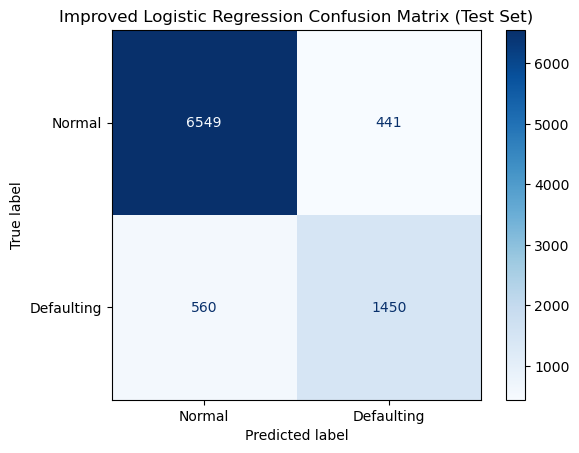

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay


# 手动输入混淆矩阵的值
cm = np.array([
    [6549,  441],  # 真实Normal样本: TN=700（预测正确）, FP=50（预测错误）
    [560,  1450]   # 真实Defaulting样本: FN=30（预测错误）, TP=220（预测正确）
])

# 根据混淆矩阵生成模拟的y_test和y_pred
TN, FP = cm[0]
FN, TP = cm[1]
y_test = [0]*(TN + FP) + [1]*(FN + TP)          # 前750个0（真实Normal），后250个1（真实Defaulting）
y_pred = [0]*TN + [1]*FP + [0]*FN + [1]*TP      # 生成对应的预测结果

# 可视化混淆矩阵
try:
    # 设置图像尺寸和分辨率
    plt.figure(figsize=(10, 8), dpi=100)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Defaulting'])
    disp.plot(cmap=plt.cm.Blues)
    
    # 设置标题
    plt.title('Improved Logistic Regression Confusion Matrix (Test Set)')
    
    # 保存高清图片
    plt.savefig(r'D:\GitHubRepos\is6400-business-data-analytics\loan_data_analytics\image\result_figs\lr_confusion_matrix_2.png', dpi=600, bbox_inches='tight')
    
    # 显示图像
    plt.show()
except Exception as e:
    print(f"\n无法显示混淆矩阵图: {e}")

<Figure size 1000x800 with 0 Axes>

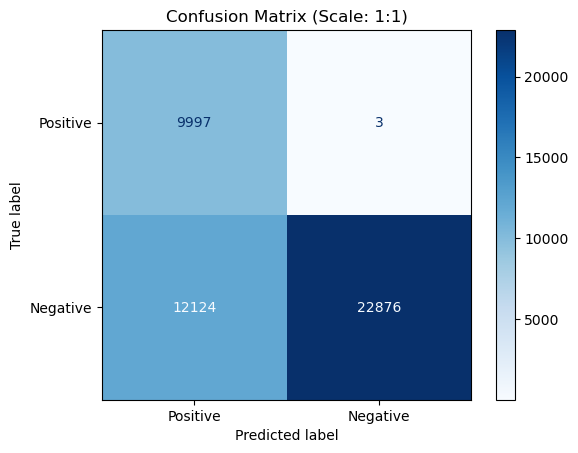

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay


# 手动输入混淆矩阵的值
cm = np.array([
    [9997,  3],  # 真实Normal样本: TN=700（预测正确）, FP=50（预测错误）
    [12124,  22876]   # 真实Defaulting样本: FN=30（预测错误）, TP=220（预测正确）
])

# 根据混淆矩阵生成模拟的y_test和y_pred
TN, FP = cm[0]
FN, TP = cm[1]
y_test = [0]*(TN + FP) + [1]*(FN + TP)          # 前750个0（真实Normal），后250个1（真实Defaulting）
y_pred = [0]*TN + [1]*FP + [0]*FN + [1]*TP      # 生成对应的预测结果

# 可视化混淆矩阵
try:
    # 设置图像尺寸和分辨率
    plt.figure(figsize=(10, 8), dpi=100)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Positive', 'Negative'])
    disp.plot(cmap=plt.cm.Blues)
    
    # 设置标题
    plt.title('Confusion Matrix (Scale: 1:1)')
    
    # 保存高清图片
    plt.savefig(r'D:\GitHubRepos\is6400-business-data-analytics\loan_data_analytics\image\result_figs\confusion_matrix_scale_1_1.png', dpi=600, bbox_inches='tight')
    
    # 显示图像
    plt.show()
except Exception as e:
    print(f"\n无法显示混淆矩阵图: {e}")